# Lab 2 — ML Primitives in NumPy

Run this notebook top to bottom as you build out `knn.py`, `gradient_descent.py`, and `pca.py` in this same folder. Each section below is a placeholder — see `Lab2_Instructions.md` for what belongs in each cell.

This notebook is just a shell: it imports your functions and gives you a place to call them, but the data generation, plotting, and test calls are yours to write.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from knn import knn_predict, predict_grid, euclidean_distance, cosine_similarity
from gradient_descent import f, grad_f, gradient_descent_1d, f2, grad_f2, gradient_descent_2d
from pca import pca_via_svd

## Part A: k-NN Classifier

In [3]:
# generating a small 2-class training set (X_train, y_train)
np.random.seed(0)
class0 = np.random.randn(30,2)

class1 = np.random.randn(30,2)+3

X_train = np.vstack((class0,class1))

y_train = np.array([0]*30+[1]*30)

k=3


In [4]:
print(X_train)
print(y_train)

[[ 1.76405235  0.40015721]
 [ 0.97873798  2.2408932 ]
 [ 1.86755799 -0.97727788]
 [ 0.95008842 -0.15135721]
 [-0.10321885  0.4105985 ]
 [ 0.14404357  1.45427351]
 [ 0.76103773  0.12167502]
 [ 0.44386323  0.33367433]
 [ 1.49407907 -0.20515826]
 [ 0.3130677  -0.85409574]
 [-2.55298982  0.6536186 ]
 [ 0.8644362  -0.74216502]
 [ 2.26975462 -1.45436567]
 [ 0.04575852 -0.18718385]
 [ 1.53277921  1.46935877]
 [ 0.15494743  0.37816252]
 [-0.88778575 -1.98079647]
 [-0.34791215  0.15634897]
 [ 1.23029068  1.20237985]
 [-0.38732682 -0.30230275]
 [-1.04855297 -1.42001794]
 [-1.70627019  1.9507754 ]
 [-0.50965218 -0.4380743 ]
 [-1.25279536  0.77749036]
 [-1.61389785 -0.21274028]
 [-0.89546656  0.3869025 ]
 [-0.51080514 -1.18063218]
 [-0.02818223  0.42833187]
 [ 0.06651722  0.3024719 ]
 [-0.63432209 -0.36274117]
 [ 2.32753955  2.64044684]
 [ 2.18685372  1.2737174 ]
 [ 3.17742614  2.59821906]
 [ 1.36980165  3.46278226]
 [ 2.09270164  3.0519454 ]
 [ 3.72909056  3.12898291]
 [ 4.13940068  1.76517418]
 

In [5]:
# TODO: pick a query point and call knn_predict to classify it
query = np.array([0, 0])

prediction = knn_predict(query, X_train, y_train, k)

print("Query Point :", query)
print("Predicted Class :", prediction)

Query Point : [0 0]
Predicted Class : 0


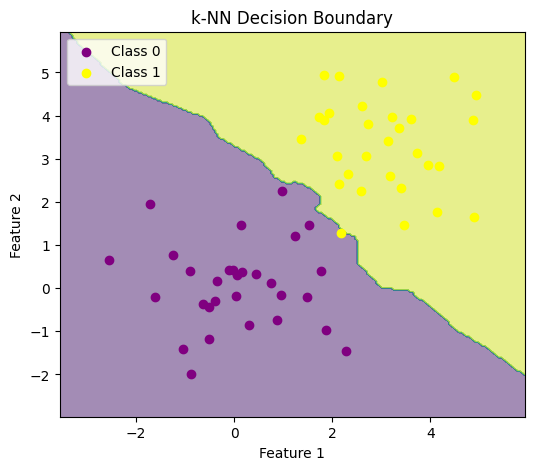

In [6]:
# TODO: build a meshgrid over the training data's range, classify every grid point,
# and plot the decision boundary with contourf (don't forget to reshape predictions to xx.shape)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
predictions = predict_grid(grid, X_train, y_train, k=3)
Z = predictions.reshape(xx.shape)
plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.5)

plt.scatter(class0[:,0], class0[:,1],
            color="purple",
            label="Class 0")

plt.scatter(class1[:,0], class1[:,1],
            color="yellow",
            label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("k-NN Decision Boundary")
plt.legend()

plt.savefig(
    "plots/knn_decision_boundary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()

## Part B: Gradient Descent

[0.         0.06       0.1188     0.176424   0.23289552 0.28823761
 0.34247286 0.3956234  0.44771093 0.49875671 0.54878158 0.59780595
 0.64584983 0.69293283 0.73907418 0.78429269 0.82860684 0.8720347
 0.91459401 0.95630213 0.99717608 1.03723256 1.07648791 1.11495815
 1.15265899]
[0.         0.6        1.08       1.464      1.7712     2.01696
 2.213568   2.3708544  2.49668352 2.59734682 2.67787745 2.74230196
 2.79384157 2.83507326 2.8680586  2.89444688 2.91555751 2.93244601
 2.9459568  2.95676544 2.96541235 2.97232988 2.97786391 2.98229113
 2.9858329 ]
[ 0.00000000e+00  7.20000000e+00 -2.88000000e+00  1.12320000e+01
 -8.52480000e+00  1.91347200e+01 -1.95886080e+01  3.46240512e+01
 -4.12736717e+01  6.49831404e+01 -8.37763965e+01  1.24486955e+02
 -1.67081737e+02  2.41114432e+02 -3.30360205e+02  4.69704287e+02
 -6.50386001e+02  9.17740402e+02 -1.27763656e+03  1.79589119e+03
 -2.50704766e+03  3.51706673e+03 -4.91669342e+03  6.89057079e+03
 -9.63959910e+03]


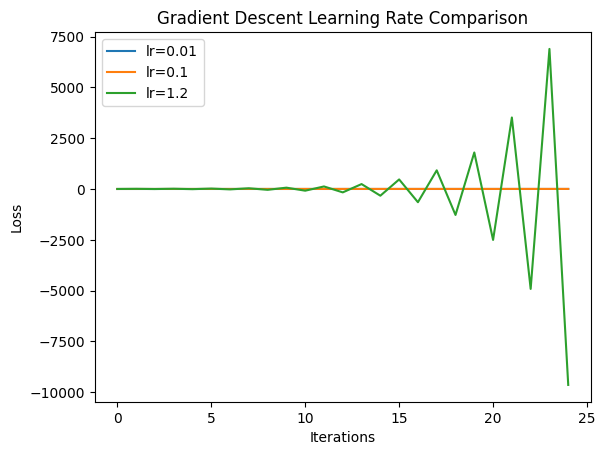

In [19]:
# TODO: run gradient_descent_1d with at least three learning rates and plot loss vs. iteration for each
# (include at least one learning rate that visibly diverges or oscillates)
lrs = [0.01, 0.1, 1.2]
for lr in lrs:
    x_final, history = gradient_descent_1d(start=0.0, lr=lr, steps=25)
    print(history)
    losses = np.array([f(x) for x in history])
    plt.plot(history, label=f"lr={lr}")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Gradient Descent Learning Rate Comparison")
plt.legend()

plt.savefig(
    "plots/gd_learning_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

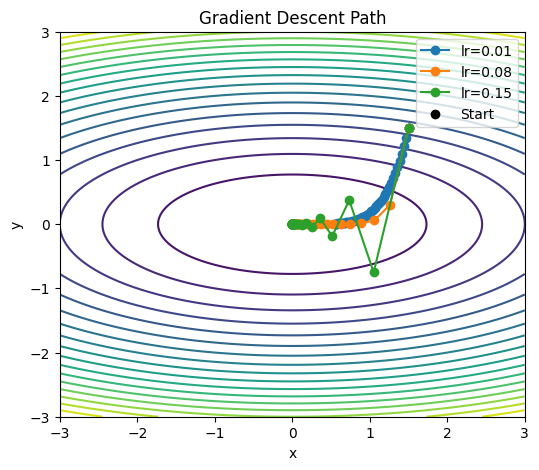

In [8]:
x_vals = np.linspace(-3, 3, 200)
y_vals = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + 5*Y**2
plt.figure(figsize=(6,5))

plt.contour(X, Y, Z, levels=20)

start_point = (1.5,1.5)

for lr in [0.01, 0.08, 0.15]:

    final_point, path = gradient_descent_2d(
        start_point,
        lr,
        50
    )

    plt.plot(path[:,0],
             path[:,1],
             marker='o',
             label=f"lr={lr}")

plt.scatter(start_point[0],
            start_point[1],
            color='black',
            label="Start")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Descent Path")
plt.legend()

plt.savefig("plots/gd_2d_path.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Part C: PCA Via SVD

In [9]:
# TODO: generate a 2D dataset with an obvious principal direction (e.g. y = 2x + noise)
np.random.seed(0)

x = np.random.randn(100)

y = 2*x + np.random.randn(100)*0.5

data = np.column_stack((x,y))

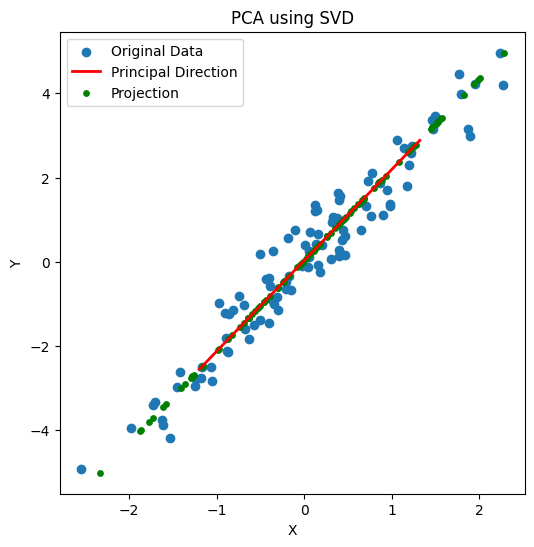

In [10]:
# TODO: call pca_via_svd, then plot the original (centered) data, the principal direction,
# and the projection together on one chart
projected, components = pca_via_svd(data,1)
center = data.mean(axis=0)
direction = components[0]

plt.figure(figsize=(6,6))

plt.scatter(data[:,0],
            data[:,1],
            label="Original Data")

t = np.linspace(-3,3,100)

line = center + np.outer(t,direction)

plt.plot(line[:,0],
         line[:,1],
         color="red",
         linewidth=2,
         label="Principal Direction")

projected_points = projected @ components + center

plt.scatter(projected_points[:,0],
            projected_points[:,1],
            color="green",
            s=15,
            label="Projection")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("PCA using SVD")
plt.legend()

plt.savefig("plots/pca_svd.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
